In [ ]:
import pandas as pd
import numpy as np

mental = 'https://raw.githubusercontent.com/mdenisennko/hse/refs/heads/main/mental_health_dataset.csv'
data = pd.read_csv(mental)
data.shape

(1000, 12)

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("mental_health_dataset.csv")
data.shape

(1000, 12)

1000 строк, 12 столбцов

In [ ]:
data.dtypes

,0
User_ID,int64
Age,int64
Gender,object
Occupation,object
Country,object
Mental_Health_Condition,object
Severity,object
Consultation_History,object
Stress_Level,object
Sleep_Hours,float64


Количественные признаки: Age, Sleep_Hours, Work_Hours, Physical_Activity_Hours

Категориальные признаки: Gender, Occupation, Country, Mental_Health_Condition, Severity,
Consultation_History, Stress_Level

Номинальные: Severity, Stress_Level

В колонке severity 501 пропуск, колонку необходимо удалить, так как пропусков более 40%

In [ ]:
data.isna().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Country,0
Mental_Health_Condition,0
Severity,501
Consultation_History,0
Stress_Level,0
Sleep_Hours,0


In [ ]:
# Удаляем колонку 'Severity'
df = data.drop('Severity', axis = 1)

df[df.duplicated()].shape[0]

0

В данных отсутствуют полные дубликаты

In [ ]:
# Определение выбросов методом IQR (межквартильный размах)
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5
up1 = q3 + iqr*1.5
print(df[(df['Age']<low1) | (df['Age']>up1)].shape[0])

q1a=df['Sleep_Hours'].quantile(0.25)
q3a=df['Sleep_Hours'].quantile(0.75)
iqra = q3a-q1a
low2 = q1a - iqra*1.5
up2 = q3a + iqra*1.5
print(df[(df['Sleep_Hours']<low2) | (df['Sleep_Hours']>up2)].shape[0])

q1b=df['Work_Hours'].quantile(0.25)
q3b=df['Work_Hours'].quantile(0.75)
iqrb = q3b-q1b
low3 = q1b - iqrb*1.5
up3 = q3b + iqrb*1.5
print(df[(df['Work_Hours']<low3) | (df['Work_Hours']>up3)].shape[0])

q1c=df['Physical_Activity_Hours'].quantile(0.25)
q3c=df['Physical_Activity_Hours'].quantile(0.75)
iqrc = q3c-q1c
low4 = q1c - iqrc*1.5
up4 = q3c + iqrc*1.5
print(df[(df['Physical_Activity_Hours']<low4) | (df['Physical_Activity_Hours']>up4)].shape[0])

0
0
0
0


В столбцах Age, Sleep_Hours, Work_Hours и Physical_Activity_Hours отсутствуют выбросы (количество выбросов = 0)

In [ ]:
df_no_userid = df.drop(df.columns[0], axis=1)
df_no_userid.describe()

,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.89200,7.095600,54.621000,5.134000
std,13.97475,1.713861,14.709035,3.081808
min,18.00000,4.000000,30.000000,0.000000
25%,30.00000,5.600000,42.000000,3.000000
50%,42.00000,7.100000,55.000000,5.000000
75%,54.00000,8.500000,67.000000,8.000000
max,65.00000,10.000000,80.000000,10.000000


1. Age: Минимальный возраст 18 лет и максимальный 65 лет говорят о широком диапазоне возрастов, что позволяет анализировать ментальное здоровье в разных жизненных фазах.
2. Sleep_Hours: Среднее значение Sleep_Hours приблизительно равно 7, что означает, что в среднем люди соблюдают
рекомендации по здоровому сну (7-8 часов), тем не менее 50% опрошенных спят менее 7.1 часов, что может негативно сказываться на их ментальном здоровье
3. Work_Hours: По данным на 2024 год, в среднем по миру продолжительность рабочей недели может варьироваться от менее 40 до почти 50 часов. Тем не менее, в среднем люди работают 54.6 часов в неделю (50% работают более 55 часов). Переработки и слишком напряженный график могут стать причиной депрессивных состояний, связанных именно с переутомлением.

In [ ]:
df.describe(include = 'object')

,Gender,Occupation,Country,Mental_Health_Condition,Consultation_History,Stress_Level
count,1000,1000,1000,1000,1000,1000
unique,4,7,7,2,2,3
top,Female,Other,Australia,Yes,No,High
freq,270,161,160,515,505,342


In [ ]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
High,342
Low,338
Medium,320


Выборка достаточно репрезентативна, так как включает людей разных профессий, полов, с разным уровнем стресса, проживающих в разных странах, имеющих и не имеющих проблем с ментальным здоровьем
1. Stress_Level: Несмотря на то, что количество респондентов, имеющих сильный, средний и низкий уровни стресса распределено равномерно, больше всего людей (342) имеют высокий уровень стресса. Сильный стресс может быть вызван внешними или внутренними факторами, такими как тяжелая работа, недосып или психоэмоциональное состояние (например, депрессии или тревожные расстройства).
2. Mental_Health_Condition/Consultation_History: количество людей, заявивших о наличии ментальных проблем составляет 515, однако лишь 495 человек консультировались с психологами и психотерапевтами (Consultation_History: freq 505, top No). Можно сделать вывод, что не все люди, осознающие наличие психических проблем обращаются за помощью и консультацией. Это подчеркивает важность повышения осведомленности о значении психического здоровья, устранения стигматизации в отношении ментальных проблем и улучшения доступа к услугам психологов и психотерапевтов для более широких слоев населения.

Text(0.5, 1.0, 'Наличие ментальных проблем')

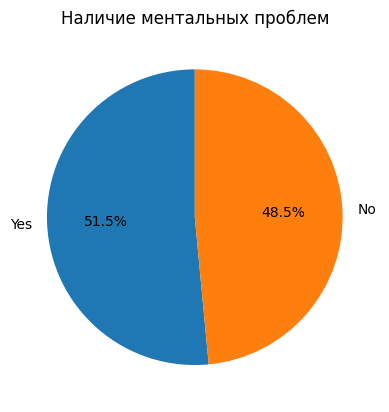

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

mental_health = df['Mental_Health_Condition'].value_counts()
plt.pie(mental_health.values, labels=mental_health.index, autopct='%1.1f%%', startangle=90)
plt.title('Наличие ментальных проблем')

На основании круговой диаграммы можно сделать вывод, что более половины опрошенных заявили о наличии ментальных проблем. Это может свидетельствовать о растущем внимании к вопросам ментального здоровья.

Text(0, 0.5, 'Количество человек')

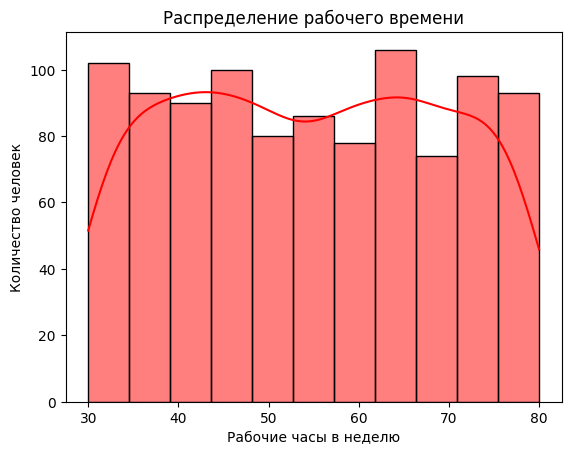

In [ ]:
sns.histplot(df['Work_Hours'], kde=True, color='red')
plt.title('Распределение рабочего времени')
plt.xlabel('Рабочие часы в неделю')
plt.ylabel('Количество человек')

Гистограмма достаточно однородна. На основании графика можно сделать вывод, что многие сотрудники работают значительно больше стандартного рабочего времени, большое количество сотрудников работает в районе 65 часов в неделю.

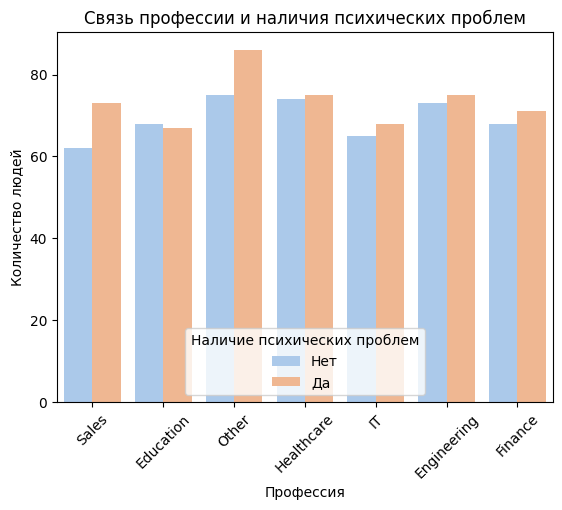

In [ ]:
sns.countplot(x='Occupation', hue='Mental_Health_Condition', data=df, palette='pastel')
plt.title('Связь профессии и наличия психических проблем')
plt.xlabel('Профессия')
plt.ylabel('Количество людей')
plt.xticks(rotation=45)
plt.legend(title='Наличие психических проблем', labels=['Нет', 'Да'], loc='lower center')

Датасет охватывает большое количество профессий из разных сфер, несмотря на то, что количество людей, работающих в медицине, IT, инженеринге и финансах, с диагностированными психическими расстройствами и не имеющиими их,  распределены примерно одинаково, в продажах и других работников с психическими проблемами больше, чем без них. Единственная сфера, в которой количество людей без психических проблем превосходит число людей с ментальными проблемами - это образование (education).

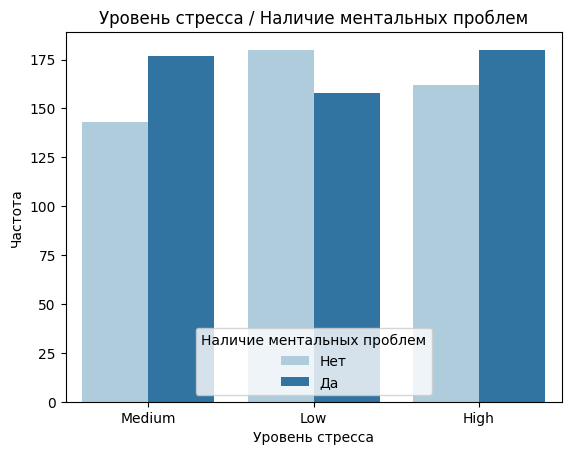

In [ ]:
sns.countplot(x='Stress_Level', hue='Mental_Health_Condition', data=df, palette='Paired')
plt.title('Уровень стресса / Наличие ментальных проблем')
plt.xlabel('Уровень стресса')
plt.ylabel('Частота')
plt.legend(title='Наличие ментальных проблем', labels=['Нет', 'Да'], loc='lower center')

На основании графика можно сделать вывод, что не всегда высокий уровень стресса является причиной ментальных проблем, он может быть и следствием, судя по тому, что среди людей со средним уровнем стресса тоже достаточно распространены психические проблемы. Низкий уровень стресса может быть привычен многим людем и не вызывать ментальных проблем, так как количество людей без психических заболеваний в этой категории больше, чем число людей, испытывающих низкий уровень стресса и определенные ментальные проблемы.

КТ-3 Корреляция. Задача регрессии или классификации

In [ ]:
df.drop(columns=['User_ID']).corr(numeric_only=True).round(3)

,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours
Age,1.000,-0.043,-0.014,0.053
Sleep_Hours,-0.043,1.000,-0.006,-0.015
Work_Hours,-0.014,-0.006,1.000,0.039
Physical_Activity_Hours,0.053,-0.015,0.039,1.000


In [ ]:
df.drop(columns=['User_ID']).corr(method="spearman", numeric_only=True).round(3)

,Age,Sleep_Hours,Work_Hours,Physical_Activity_Hours
Age,1.000,-0.045,-0.014,0.053
Sleep_Hours,-0.045,1.000,-0.005,-0.015
Work_Hours,-0.014,-0.005,1.000,0.039
Physical_Activity_Hours,0.053,-0.015,0.039,1.000


<Axes: >

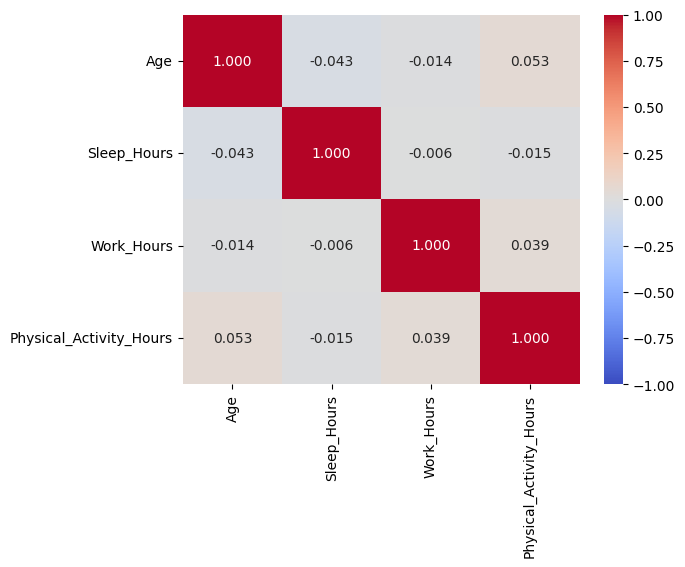

In [ ]:
sns.heatmap(
    data=df.drop(columns=['User_ID']).corr(numeric_only=True),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".3f")

r = 0.053 (признаки Age и Physical_Activity_Hours)

r>0: положительная (прямая) связь, но значение крайне близко к 0, зависимость практически отсутствует

|r|<0.3: очень слабая связь, практически отсутствует

Text(0, 0.5, 'Physical Activity Hours')

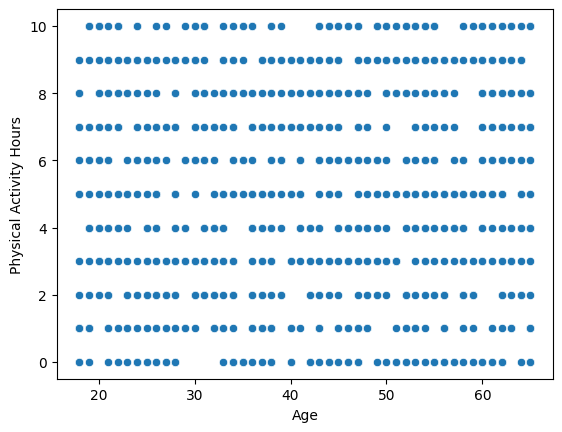

In [ ]:
sns.scatterplot(data=df, x="Age", y="Physical_Activity_Hours")
plt.xlabel("Age")
plt.ylabel("Physical Activity Hours")

Диаграмма рассеяния подтверждает отсутствие зависимости

Логистическая регрессия (предсказание наличия ментального заболевания)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours']]
y = df['Mental_Health_Condition'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X_train, y_train)
print(model.coef_)
print(model.intercept_.round(2))

[[ 0.00096708 -0.01986749  0.006012   -0.00018053]]
[-0.14]


Age (0.00096), Work_Hours (0.00601)
При увеличении взраста и рабочих часов вероятность того, что у челвека будет ментальное заболевание, будет увеличиваться, но незначительно (чем старше человек или чем больше он работает, тем выше стресс)

Sleep_Hours (-0.01987)
При уменьшении длительности сна (в часах) вероятность того, что у человека будет ментальное заболевание, будет увеличиваться (лучший сон может уменьшать психические проблемы)
Physical_Activity_Hours (-0.00018)
При уменьшении длительности физической активности (в часах) вероятность того, что у человека будет ментальное заболевание, будет увеличиваться (эффект минимален)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))

y_pred_proba = model.predict_proba(X_test)
print("log_loss:", log_loss(y_test, y_pred_proba))

print("ROC_AUC:", roc_auc_score(y_test, y_pred_proba[:, 1]))

Accuracy: 0.495
Recall: 0.847
F1 Score: 0.622
Precision: 0.491
log_loss: 0.69444063987628
ROC_AUC: 0.5190076030412165


Оценка качества модели

Низкие значения accuracy, precision и ROC-AUC указывают на то, что модель не превосходит случайный выбор. Модель обладает плохой прогностической способностью.

Интерпретация метрик

Accuracy = 0.495: Модель с точностью 49,5% делает верный прогноз, что меньше 50%

Precision = 0.491: Модель не надежна при классификации Positive семплов

Recall = 0.847: Примерно 85% Positive выборок было корректно предсказано. Модель достаточно хорошо классифицирует представителей положительного класса.

Модель имеет достатосно высокий уровень recall метрики, но низкую percision, модель правильно определяет большинство positive семплов, но имеет много ложных срабатываний (классификаций Negative выборок как Positive)

F1 = 0.622: у модели естьп роблемы с достижением баланса между полнотой и точностью

Log_loss = 0.69: прогнозируемая вероятность достаточно сильно отклоняется от фактического значения

ROC_AUC: 0.52: показатель практически равен 0.5, практически не лучше случайного угадывания


In [ ]:
import sklearn

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
regressor = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)

regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, oob_score=True, random_state=0)

Дополнительная часть.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')
oob_error = 1 - regressor.oob_score
print(f'oob error: {oob_error:.3f}')

predictions = regressor.predict(X_train)

mse = mean_squared_error(y_train, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y_train, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: -0.45060052481194957
oob error: 0.000
Mean Squared Error: 0.053137500000000004
R-squared: 0.7870653868550069


Оценка показателей:

R2: Чем ближе коэффициент детерминации к 1, тем модель лучше. В нашем случае модель явлется хорошей, даже приближается к отличной, тк показатель r2>0.7.
MSE: Среднеквадратичная ошибка является низкой, что дает понять, модель почти не ошибается.

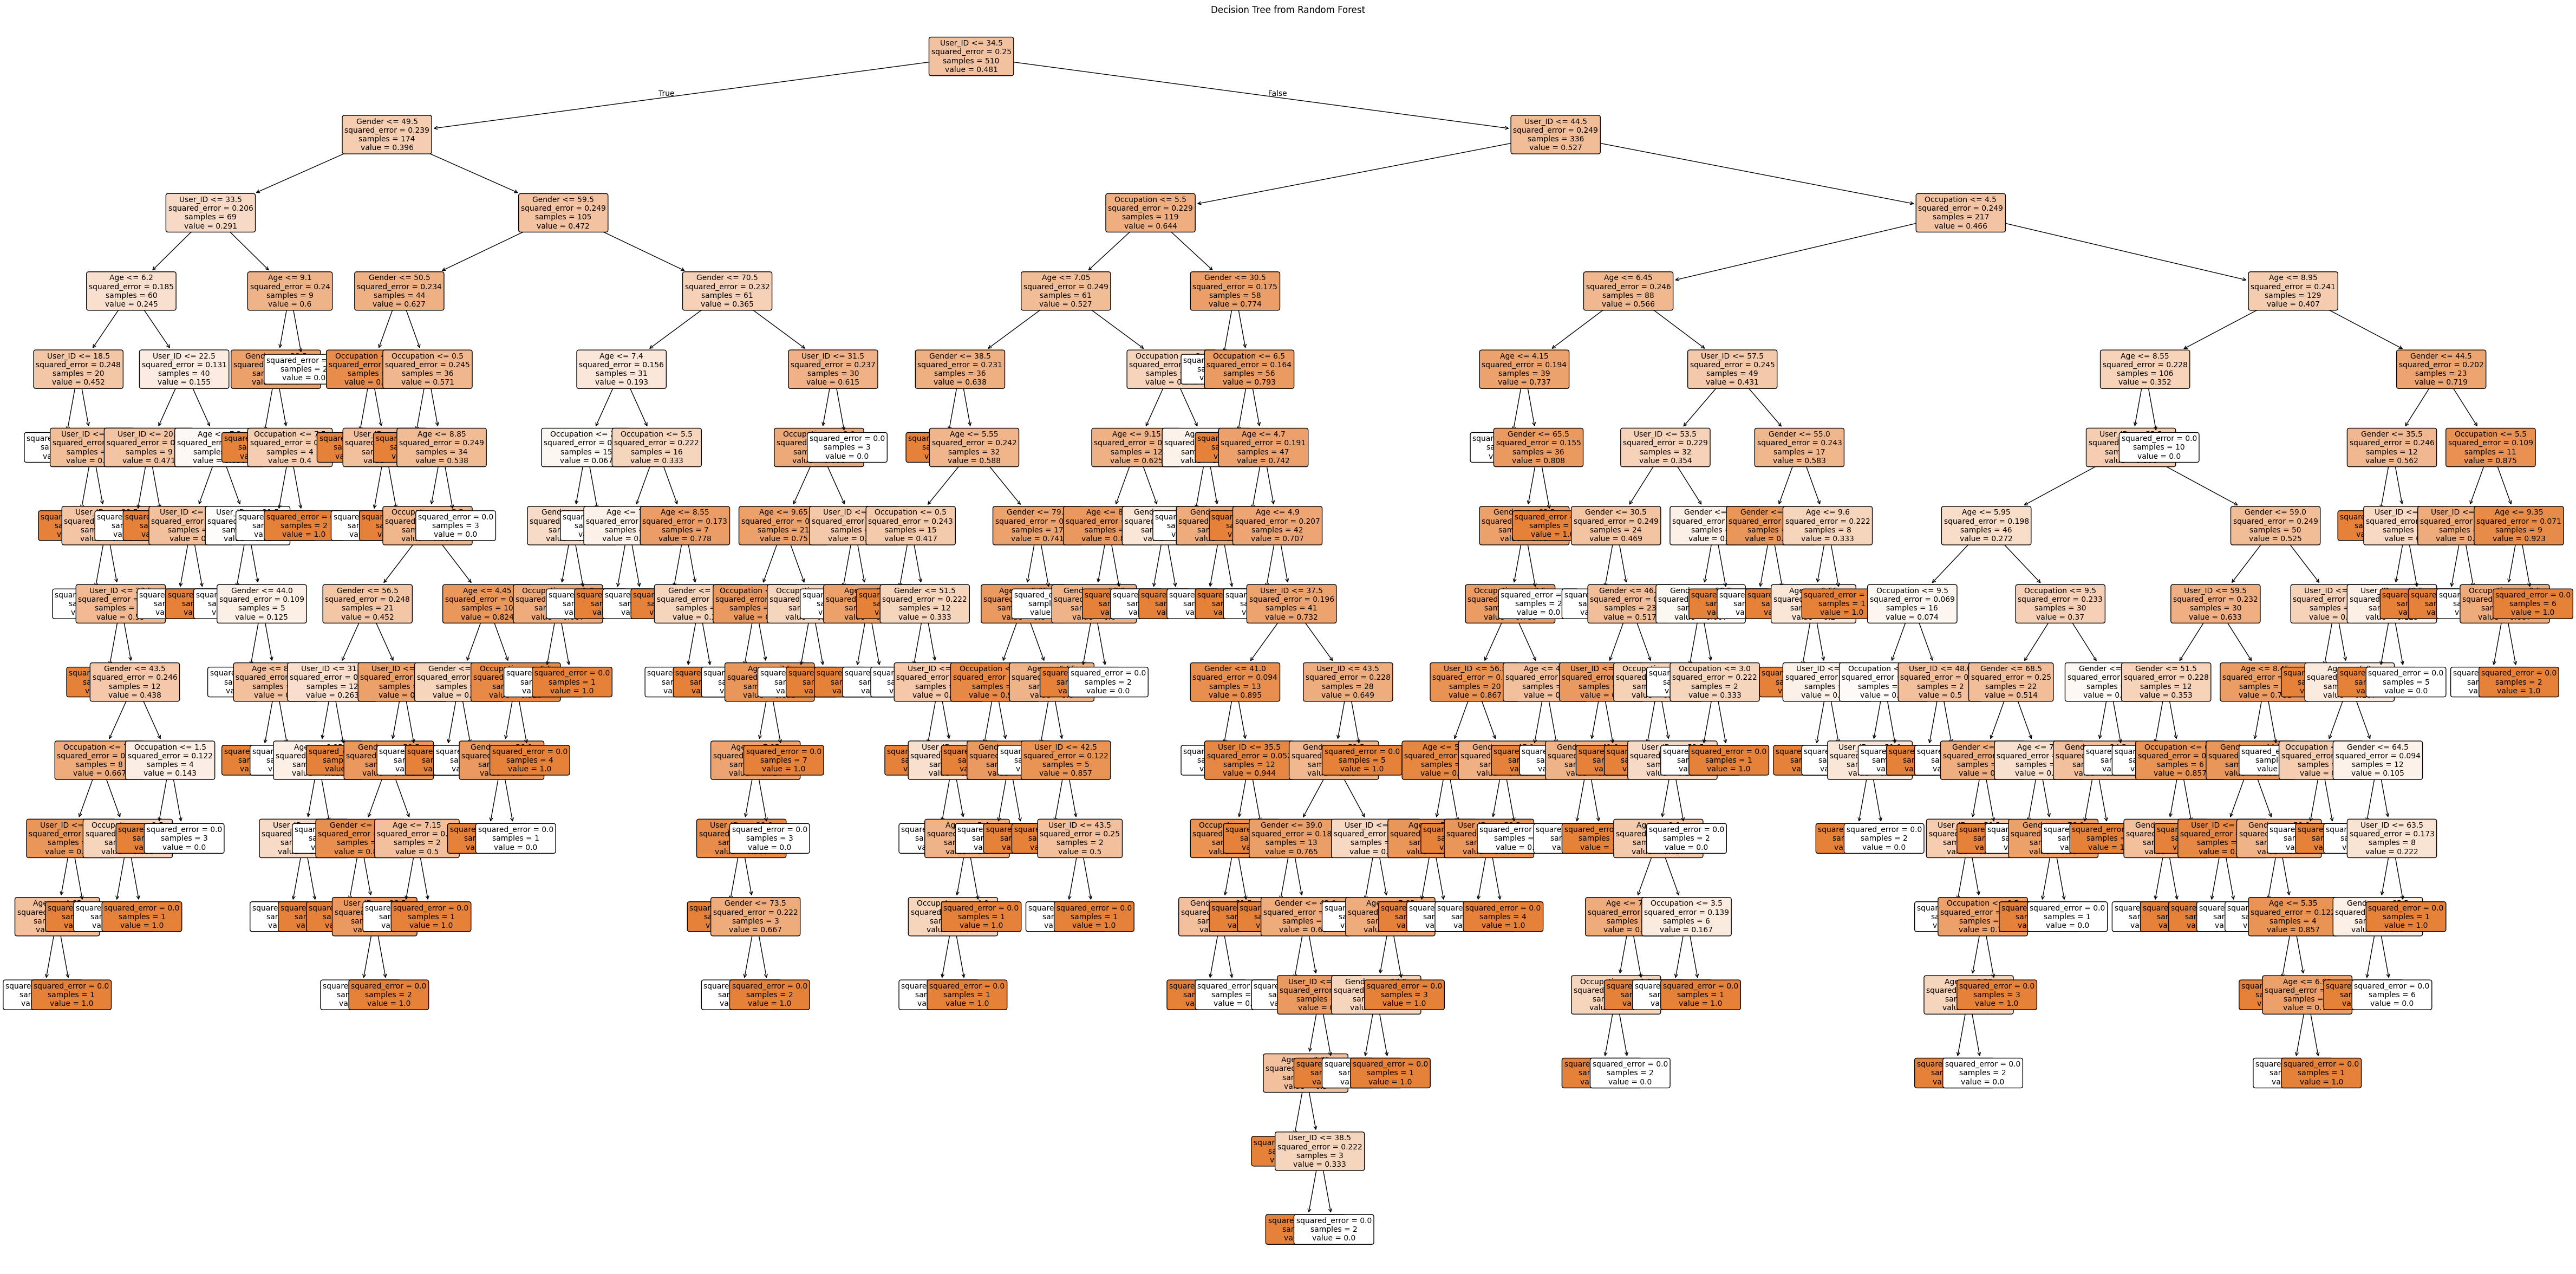

In [ ]:
from sklearn.tree import plot_tree

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(60, 30))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()

Достоинства "случайного леса":
*Устойчивость к переобучению - За счет использования подвыборок и случайных признаков метод случайного леса менее подвержен переобучению. Это особенно важно при работе с большими и сложными наборами данных.
*Обработка пропущенных данных - Алгоритм может работать с пропущенными данными, что делает его более гибким. Это достигается за счет использования различных стратегий заполнения пропусков и учета неопределенности в данных.
*Устойчивость к выбросам - Случайный лес меннее чувствителен к выбросам.
*Нет необходимости масштабирования признаков - В отлчие от других алгоритмов случайный лес не требует нормализации или масштабирования данных.

Недостатки:
*Меньше интерпретируемость - Поскольку используется больше деревьев, возможны трудности в восприятии.
*Сложность - обучение может быть затратным и более медленным из-за работы с большим кол-вом данных (деревьев)
*Чувствителен к несбалансированным данным - если в наборе данных встречаются сильно несбалансированные, например, один класс встречается сильно больше остальных.

Немного сбалансировали наше "дерево", чтобы предотвратить переобучение:

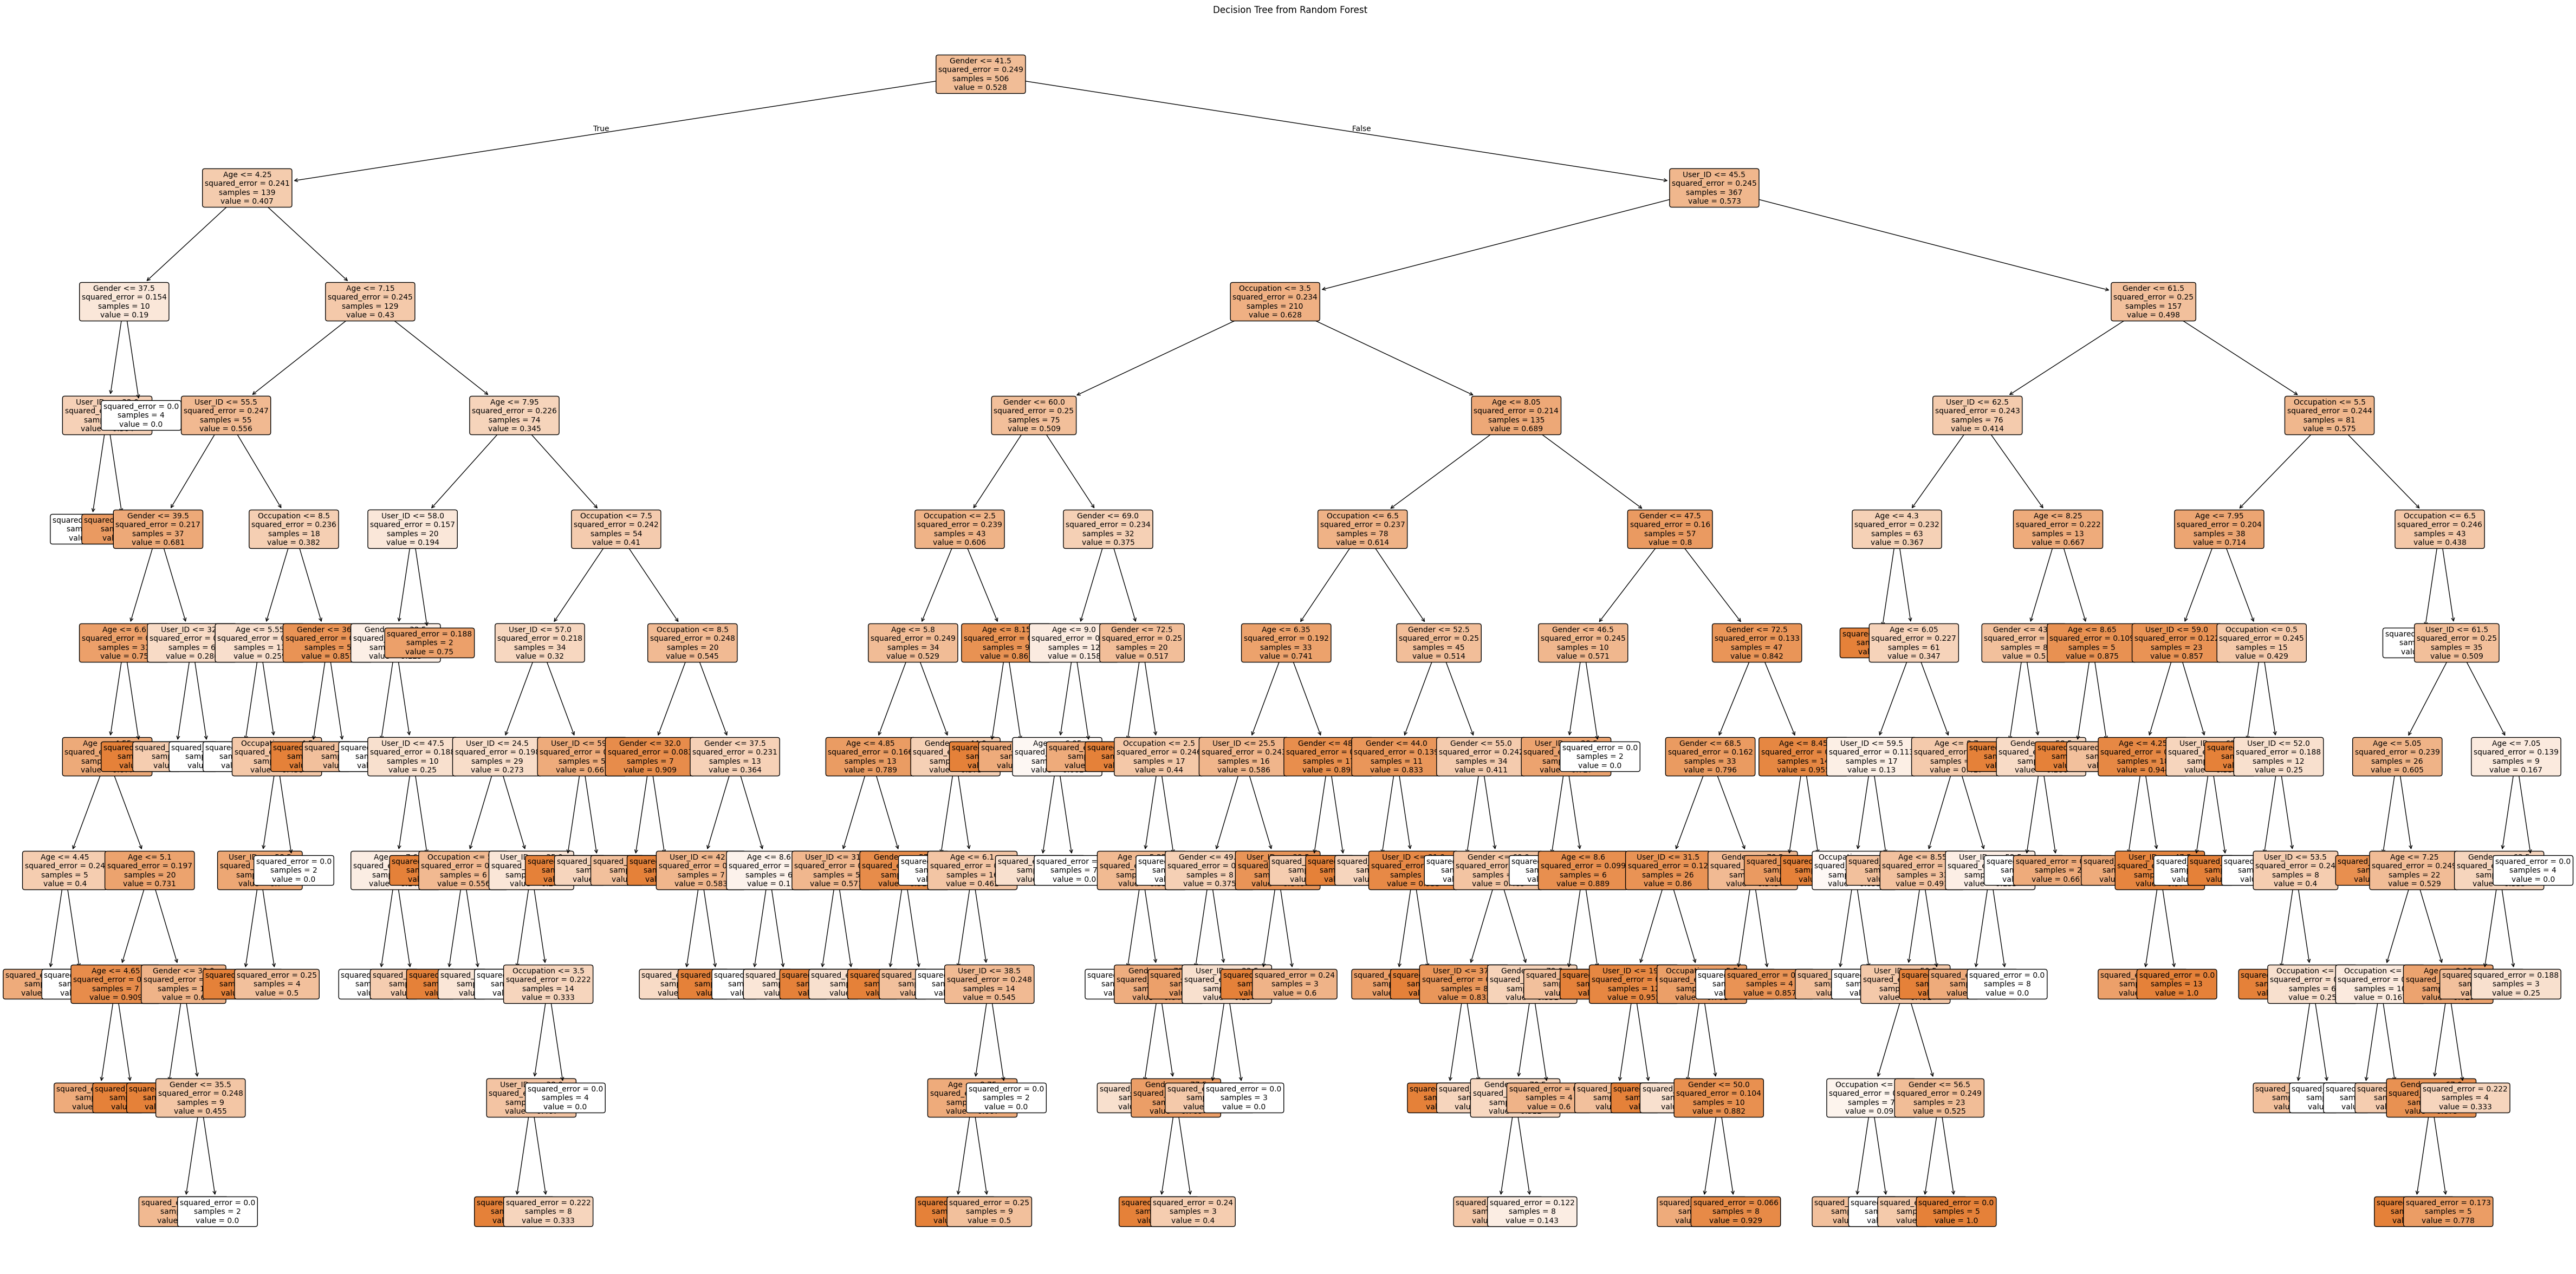

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

regressor = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
regressor.fit(X_train, y_train)

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(60, 30))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()


КТ-4

1. Доверительный интервал для математического ожидания через z-статистику

In [ ]:
import scipy.stats as stats

sleep = df['Sleep_Hours']
n = len(sleep)
mean = sleep.mean()
s = np.std(sleep)

res = stats.norm.interval(0.99, loc=mean, scale=s/np.sqrt(n))
res

(6.956067523011886, 7.235132476988114)

С вероятностью 99% среднее время сна находится в интервале от 6.956 до 7.235 часов

2. Доверительный интервал для математического ожидания через t-статистику

In [ ]:
res = stats.t.interval(0.99,
                       df = n - 1,
                       loc = mean,
                       scale = s/np.sqrt(n))
res

(6.9558004472102395, 7.235399552789761)

С вероятностью 99% среднее время сна находится в интервале от 6.956 до 7.235

3. Z-тест на математическое ожидание

H0: Среднее количество сна у людей с ментальными заболеваниями равно 7 часам

H1: Среднее количество сна у людей с ментальными заболеваниями не равно 7 часам.

In [ ]:
from statsmodels.stats.weightstats import ztest

df_mental = df[df["Mental_Health_Condition"] == "Yes"]

mu = 7

from statsmodels.stats.weightstats import ztest as ztest
res = ztest(df_mental["Sleep_Hours"],
            value = mu,
            alternative = 'two-sided')
p_value

np.float64(0.4998387413451688)

p-value = 0.5, гипотеза не отвергается при уровне значимости 10%

Вывод: Среднее количество сна у людей с ментальными заболеваниями статистически не отличается от 7 часов.

Это означает, что количество сна у этой группы не является аномальным и, вероятно, не связано напрямую с наличием ментального заболевания.

4. T-тест на математическое ожидание

In [ ]:
from scipy import stats
res = stats.ttest_1samp(df_mental["Sleep_Hours"],
                        popmean=mu,
                        alternative='two-sided')  # H1: ≠
res[1] # p-value

np.float64(0.5001421187534199)

p-value = 0.5, гипотеза не отвергается при уровне значимости 10%

Вывод: Среднее количество сна у людей с ментальными заболеваниями статистически не отличается от 7 часов.
В этом тесте результаты схожи с Z-тестом.

5. Тест на равенство математических ожиданий двух выборок
   
Гипотеза: среднее рабочее время людей с ментальным заболеванием больше, чем людей без ментальных заболеваний.

H0: Среднее рабочее время людей с ментальным заболеванием и у людей без ментальных заболеваний равно.

H1: Среднее рабочее время людей с ментальным заболеванием больше, чем у людей без ментальных заболеваний.

In [ ]:
have = df[df["Mental_Health_Condition"] == 'Yes']['Work_Hours']
not_have = df[df["Mental_Health_Condition"] == 'No']['Work_Hours']

result = stats.ttest_ind(have,                       # выборка 2
                         not_have,                 # выборка 1
                         alternative = 'greater',     # >
                         equal_var=True)              # дисперсии равны
result

TtestResult(statistic=np.float64(1.179696100692594), pvalue=np.float64(0.11920111732364537), df=np.float64(998.0))

Вывод: Нулевая гипотеза не отвергается на любых уровнях допустимой значимости. Предположение о различии в длительности рабочего времени, в связи различия ментального здоровья, неверно.


6. Зависимость двух критериев в данных с помощью критерия независимости хи-квадрат

H0: В генеральной совокупности не существует зависимости между странами проживания и наличием ментального заболевания.

H1: В генеральной совокупности существует зависимость между странами, в которых проживают опрошенные и наличием ментального заболевания.

In [ ]:
ct_o = df.groupby('Country')['Mental_Health_Condition'].value_counts().unstack()
ct_o

Mental_Health_Condition,No,Yes
Country,,
Australia,87,73
Canada,59,79
Germany,74,67
India,70,85
Other,62,53
UK,67,72
USA,66,86


In [ ]:
alpha = 0.01
dof = (7-1)*(2-1)
critical_value = 16.81

In [ ]:
stats.chi2_contingency(ct_o)

Chi2ContingencyResult(statistic=8.546155787131655, pvalue=0.2007562237842514, dof=6, expected_freq=array([[77.6  , 82.4  ],
       [66.93 , 71.07 ],
       [68.385, 72.615],
       [75.175, 79.825],
       [55.775, 59.225],
       [67.415, 71.585],
       [73.72 , 78.28 ]]))

Критерий меньше критического значения (8.5 < 16.81), следовательно, нулевая гипотеза не может быть отвергнута в пользу альтернативной — в генеральной совокупности опрошенных зависимость между странами проживания и наличием ментального заболевания отсутствует.

7. Соответствия распределение двух признаков с помощью критерия согласия хи-квадрат

H0: 50% всех людей, имеющих психическое заболевание, — мужчины, и 50% — женщины.

Другими словами — разницы между долей мужчин и женщин, имеющих ментальные заболевания нет.

Н1: распределение в генеральной совокупности отличается от распределения, описанного нулевой гипотезой.

In [ ]:
ct_o1 = df.loc[(df['Gender'] != 'Prefer not to say') & (df['Gender'] != 'Non-binary') & (df['Mental_Health_Condition'] == 'Yes')].groupby('Mental_Health_Condition')['Gender'].value_counts().unstack()
ct_o1

Gender,Female,Male
Mental_Health_Condition,,
Yes,144,129


In [ ]:
alpha = 0.01
dof = 2-1
critical_value = 6.63
n_total = ct_o1.sum().sum()

ct_e = np.array([0.5*n_total, 0.5*n_total])
ct_e

array([136.5, 136.5])

In [ ]:
((ct_o1 - ct_e)**2 / ct_e).sum().sum()

0.8241758241758241

Критерий согласия хи-квадрат равен 0.82 < 6.63, нет оснований отвергать нулевую гипотезу (H₀).

Это означает, что различия между долями мужчин и женщин, имеющих ментальные заболевания, статистически незначимы.